**Install & Import Packages**

In [ ]:
!pip install -q bertopic umap-learn hdbscan sentence-transformers pymed

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

from pymed import PubMed
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, OpenAI
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import openai
from google.colab import userdata

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**PubMed Query & Corpus Construction**

In [ ]:
pubmed = PubMed(
    tool="UrbanHeatNBSProject",
    email="useyouremail@yourownemail.com"
)

# Full Boolean query aligned with proposal
query = """
(
  "green infrastructure"[Title/Abstract] OR
  "green stormwater infrastructure"[Title/Abstract] OR
  "green streets"[Title/Abstract] OR
  "green roofs"[Title/Abstract] OR
  "urban greening"[Title/Abstract] OR
  "green space"[Title/Abstract] OR
  "greenspace"[Title/Abstract] OR
  "urban vegetation"[Title/Abstract] OR
  "tree canopy"[Title/Abstract] OR
  "urban forest"[Title/Abstract] OR
  "park"[Title/Abstract] OR
  "nature based solution"[Title/Abstract] OR
  "nature-based solution"[Title/Abstract] OR
  "NBS"[Title/Abstract] OR
  "GI"[Title/Abstract] OR
  "GSI"[Title/Abstract]
)
AND
(
  urban[Title/Abstract] OR
  city[Title/Abstract] OR
  cities[Title/Abstract] OR
  metropolitan[Title/Abstract] OR
  metro[Title/Abstract]
)
AND
(
  heat[Title/Abstract] OR
  "heat exposure"[Title/Abstract] OR
  "extreme heat"[Title/Abstract] OR
  heatwave[Title/Abstract] OR
  "heat wave"[Title/Abstract] OR
  temperature[Title/Abstract] OR
  thermal[Title/Abstract] OR
  "urban heat island"[Title/Abstract] OR
  UHI[Title/Abstract] OR
  "heat stress"[Title/Abstract] OR
  "heat strain"[Title/Abstract]
)
AND
(
  health[Title/Abstract] OR
  "public health"[Title/Abstract] OR
  "heat-related illness"[Title/Abstract] OR
  "heat related illness"[Title/Abstract] OR
  "heat-related health outcome"[Title/Abstract] OR
  "heat related health outcome"[Title/Abstract] OR
  "heat stroke"[Title/Abstract] OR
  heatstroke[Title/Abstract] OR
  dehydration[Title/Abstract] OR
  morbidity[Title/Abstract] OR
  mortality[Title/Abstract] OR
  "heat mortality"[Title/Abstract] OR
  "excess mortality"[Title/Abstract] OR
  hospitalization[Title/Abstract] OR
  hospitalisation[Title/Abstract] OR
  "emergency visit"[Title/Abstract] OR
  "ER visit"[Title/Abstract] OR
  "health outcome"[Title/Abstract] OR
  "health impact"[Title/Abstract]
)
AND
(
  "2016/01/01"[Date - Publication] : "2026/12/31"[Date - Publication]
)
"""

# Retrieve up to 10,000 results
results = pubmed.query(query, max_results=10000)

articles = []
for article in results:
    abstract = article.abstract
    if abstract is not None:
        articles.append({
            "pmid": article.pubmed_id,
            "title": article.title,
            "abstract": abstract,
            "journal": getattr(article, "journal", None),
            "year": getattr(article.publication_date, "year", None)
                    if getattr(article, "publication_date", None) else None
        })

df = pd.DataFrame(articles)
print(f"Total articles retrieved: {df.shape[0]}")
df.head()

Total articles retrieved: 323


,pmid,title,abstract,journal,year
0,42114264,Cooling efficiency of urban green spaces affec...,The urban heat island effect poses considerabl...,Journal of environmental management,2026.0
1,42077508\n18925892\n34870078\n34032952\n268281...,Analysis of Spontaneous Plant Species in an Ur...,This study presents a detailed floristic inven...,"Plant-environment interactions (Hoboken, N.J.)",2026.0
2,42065509,Lifesaving Cooling Effect: Spatially Explicit ...,"Heatwaves, intensified by climate change and u...",Environmental science & technology,2026.0
3,42063020,"The interplay of heatwaves, air pollution, and...",While extreme heat represents an established r...,BMC public health,2026.0
4,42025676,"The ""green exercise"" paradox: Quantifying the ...",Exercise in polluted urban environments create...,"Environmental pollution (Barking, Essex : 1987)",2026.0


**Inclusion / Exclusion Criteria & Text Cleaning**

In [ ]:
# Keep only articles published 2016–2026
df = df[df["year"].between(2016, 2026)]

# Remove duplicates by title
df = df.drop_duplicates(subset=["title"])

# Remove missing abstracts
df = df[df["abstract"].notna()]

# --- EXCLUSION ---
# Exclude rural/non-urban/non-peer-reviewed signal terms.
# Note: editorials and letters cannot be filtered at abstract
# level alone; apply publication type filter in PubMed query
# or manually screen flagged records.
exclude_terms = [
    r"\brural\b",
    r"\bagriculture\b",
    r"\blivestock\b",
    r"\bfarmland\b",
    r"\bnon-urban\b",
    r"\bsuburban\b",       # review manually if needed
    r"\beditorial\b",
    r"\bletter to the editor\b"
]

exclude_pattern = "|".join(exclude_terms)

df = df[
    ~df["abstract"].str.contains(
        exclude_pattern,
        case=False,
        na=False,
        regex=True
    )
]

print(f"Articles after inclusion/exclusion filtering: {df.shape[0]}")


Articles after inclusion/exclusion filtering: 296


In [ ]:
base_stopwords = set(stopwords.words("english"))

# Custom stopwords: overly generic terms that dominate topics
# but do not reflect NBS type or health outcome
custom_stopwords = [
    "urban", "heat", "temperature", "health", "study", "studies",
    "results", "effect", "effects", "using", "used", "city", "cities",
    "public", "areas", "associated", "exposure", "also", "may",
    "however", "showed", "found", "significantly"
]
all_stopwords = base_stopwords.union(custom_stopwords)

def clean_text(text):
    """Lowercase, remove punctuation/numbers, remove stopwords."""
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = " ".join([w for w in text.split() if w not in all_stopwords])
    return text

df["clean_abstract"] = df["abstract"].apply(clean_text)
print(f"Cleaned corpus size: {df.shape[0]} abstracts")

Cleaned corpus size: 296 abstracts


**Text Representation — Sentence Embeddings (Primary)   & TF-IDF (Baseline)**

In [ ]:
docs = df["clean_abstract"].tolist()

# Primary: Sentence-BERT embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(docs, show_progress_bar=True)

# Baseline: TF-IDF matrix (used in Section 6)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(docs)

print("Embeddings shape:", embeddings.shape)
print("TF-IDF matrix shape:", X_tfidf.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embeddings shape: (296, 384)
TF-IDF matrix shape: (296, 5000)


**Topic Discovery — BERTopic (Primary Method)**

In [ ]:
import random
np.random.seed(42)
random.seed(42)

In [ ]:
from umap import UMAP

In [ ]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)


In [ ]:
vectorizer_model = CountVectorizer(
    stop_words=list(all_stopwords),
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95
)

# Seed topics aligned with proposal NBS types and outcomes
seed_topic_list = [
    ["green roof", "roof vegetation", "rooftop greening"],
    ["urban forest", "tree canopy", "street trees"],
    ["park", "greenspace", "green space"],
    ["wetland", "bioswale", "blue-green infrastructure"],
    ["mortality", "hospitalization", "heat stroke", "morbidity"],
    ["heat island", "cooling effect", "surface temperature"]
]

representation_model = KeyBERTInspired()

# nr_topics = 10 as upper bound per proposal (k = 6–10)
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    seed_topic_list=seed_topic_list,
    nr_topics=10,
    min_topic_size=15,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

# Store assigned topic per abstract
df["bertopic_topic"] = topics

topic_info = topic_model.get_topic_info()
print(topic_info)


2026-05-20 23:36:46,676 - BERTopic - Guided - Find embeddings highly related to seeded topics.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-20 23:36:46,751 - BERTopic - Guided - Completed ✓
2026-05-20 23:36:46,754 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-20 23:36:59,340 - BERTopic - Dimensionality - Completed ✓
2026-05-20 23:36:59,341 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-20 23:36:59,359 - BERTopic - Cluster - Completed ✓
2026-05-20 23:36:59,361 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-20 23:36:59,539 - BERTopic - Representation - Completed ✓
2026-05-20 23:36:59,541 - BERTopic - Topic reduction - Reducing number of topics
2026-05-20 23:36:59,541 - BERTopic - Topic reduction - Number of topics (10) is equal or higher than the clustered topics(5).
2026-05-20 23:36:59,544 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-20 23:37:03,921 - BERTopic - Representation - Completed ✓


   Topic  Count                                               Name  \
0     -1    106  -1_air quality_meteorological_hazards_sustainable   
1      0    117          0_tree planting_tree canopy_forests_trees   
2      1     19  1_birth outcomes_asthma_vegetation index_natur...   
3      2     32  2_environmental exposures_impact assessment_su...   
4      3     22  3_sustainability_environmental exposures_initi...   

                                      Representation  \
0  [air quality, meteorological, hazards, sustain...   
1  [tree planting, tree canopy, forests, trees, e...   
2  [birth outcomes, asthma, vegetation index, nat...   
3  [environmental exposures, impact assessment, s...   
4  [sustainability, environmental exposures, init...   

                                 Representative_Docs  
0  [cardiovascular disease cvd leading cause mort...  
1  [island uhi mainly nocturnal phenomenon appear...  
2  [climate change impacted diurnal range dtr par...  
3  [important driving 

**TF-IDF Baseline Comparison — K-Means (k = 6–10)**

k=6  Silhouette Score: 0.0038
k=7  Silhouette Score: 0.0033
k=8  Silhouette Score: 0.0039
k=9  Silhouette Score: 0.0037
k=10  Silhouette Score: 0.0042

Best k (TF-IDF baseline): 10


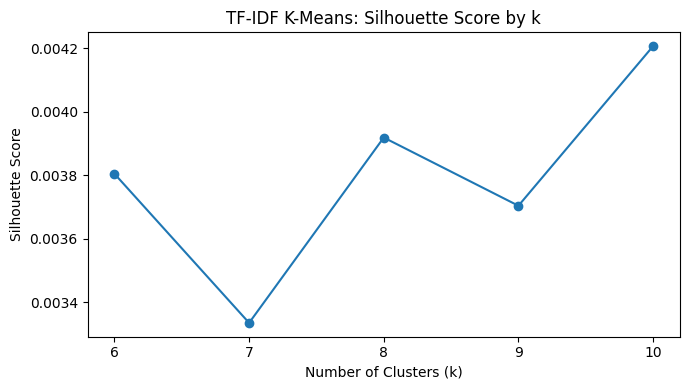

In [ ]:
k_range = range(6, 11)
silhouette_scores = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tfidf)
    score = silhouette_score(X_tfidf, labels, sample_size=1000)
    silhouette_scores[k] = score
    print(f"k={k}  Silhouette Score: {score:.4f}")

# Select k with highest silhouette score
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k (TF-IDF baseline): {best_k}")

# Refit with best k and store labels
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["tfidf_cluster"] = kmeans_final.fit_predict(X_tfidf)

# Visualize silhouette scores
plt.figure(figsize=(7, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.title("TF-IDF K-Means: Silhouette Score by k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()


**LLM-Assisted Cluster Labeling (OpenAI GPT-4o-mini)**

In [ ]:
from google.colab import userdata

client = openai.OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

# Update BERTopic representation model to use OpenAI
llm_representation_model = OpenAI(
    client,
    model="gpt-4o-mini",
    chat=True,
    prompt="""
I have a topic described by the following keywords: [KEYWORDS].
Using ONLY these keywords and the abstracts below, provide a short
2–5 word label for this topic that reflects the type of nature-based
solution or health outcome described.
Do NOT introduce information beyond what is provided.
Topic keywords: [KEYWORDS]
"""
)

topic_model.update_topics(
    docs,
    representation_model=llm_representation_model
)

topic_info_llm = topic_model.get_topic_info()
print(topic_info_llm[["Topic", "Count", "Name"]].to_string())


100%|██████████| 5/5 [00:03<00:00,  1.38it/s]

   Topic  Count                                     Name
0     -1    106        -1_Greenspace and Health Outcomes
1      0    117           0_Urban Heat Island Mitigation
2      1     19      1_Greenspace and Respiratory Health
3      2     32  2_Urban Environmental Health Assessment
4      3     22         3_Green Spaces and Mental Health


**LLM Evidence Map Summaries (per cluster)**

In [ ]:
def generate_cluster_summary(topic_id, topic_model, df, client):
    """
    Generate a 1–2 paragraph evidence summary for a given BERTopic topic.
    Guardrails: summarize only from provided abstracts,
    cite PMIDs, do not add outside facts.
    """
    # Get representative abstracts and their PMIDs
    rep_docs = topic_model.get_representative_docs(topic_id)
    pmids = df[df["clean_abstract"].isin(rep_docs)]["pmid"].tolist()
    pmid_str = ", ".join([str(p) for p in pmids]) if pmids else "PMIDs unavailable"

    abstracts_text = "\n\n".join(
        [f"[PMID: {p}]\n{a}" for p, a in zip(pmids, rep_docs)]
    ) if pmids else "\n\n".join(rep_docs)

    prompt = f"""
You are a public health research assistant conducting a rapid evidence map.

TASK: Write a 1–2 paragraph summary of the following PubMed abstracts.

STRICT RULES — you must follow all of these:
1. Use ONLY information present in the provided abstracts.
2. Do NOT add any facts, statistics, or claims not found in the abstracts.
3. Cite the PMID of each abstract you reference, in parentheses (e.g., PMID: 12345678).
4. Focus your summary on:
   a) The type(s) of nature-based solution (NBS) discussed
   b) The urban heat outcomes reported
   c) The health outcomes reported (if any)
5. If information on any of the above is absent, state that explicitly.

Abstracts:
{abstracts_text}

Referenced PMIDs: {pmid_str}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content


# Generate summaries for all non-outlier topics
summaries = {}
topic_ids = topic_info_llm[topic_info_llm["Topic"] != -1]["Topic"].tolist()

for topic_id in topic_ids:
    print(f"\n--- Generating summary for Topic {topic_id} ---")
    summary = generate_cluster_summary(topic_id, topic_model, df, client)
    summaries[topic_id] = summary
    print(summary)

# Store summaries in a DataFrame for reporting
summary_df = pd.DataFrame({
    "Topic": list(summaries.keys()),
    "LLM_Label": [topic_info_llm[topic_info_llm["Topic"] == t]["Name"].values[0]
                  for t in summaries.keys()],
    "Summary": list(summaries.values())
})
print(summary_df[["Topic", "LLM_Label"]].to_string())

#


--- Generating summary for Topic 0 ---
The abstracts discuss various nature-based solutions (NBS) related to urban heat outcomes and their consequent health implications. The first abstract (PMID: 38159755) emphasizes the role of increased tree coverage in mitigating urban heat island (UHI) effects in Mexico, noting that heightened tree canopy cannot, by itself, adequately address UHI without careful selection of appropriate tree species. The second abstract (PMID: 26828171) presents the multifaceted role of trees in urban landscapes, including their cooling benefits through transpiration and canopy shade, while also acknowledging potential adverse impacts on air quality due to the release of volatile organic compounds. It suggests that a better understanding of these dynamics is crucial for enhancing urban well-being. The third abstract (PMID: 26828167) highlights the challenge posed by recurrent heatwaves and drought on periurban forests in Germany, documenting tree crown dieback an

**Time-Trend Visualization**


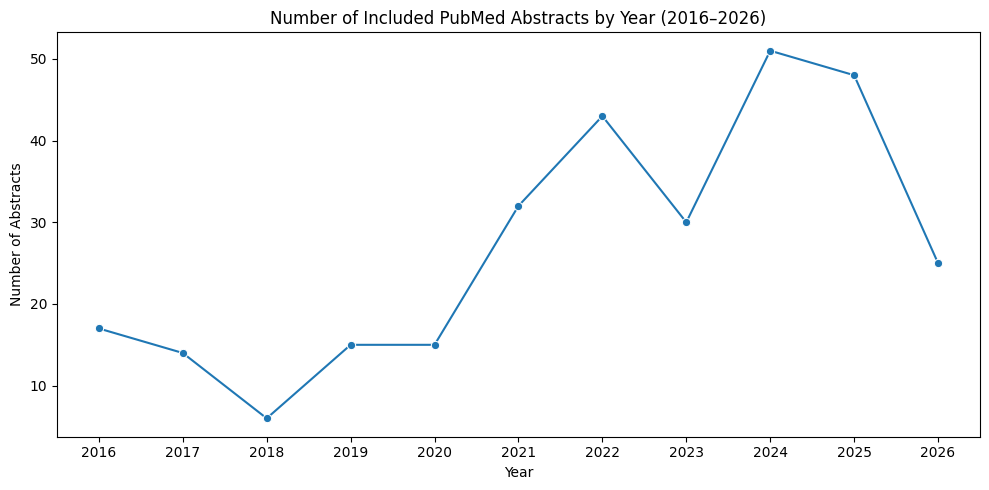

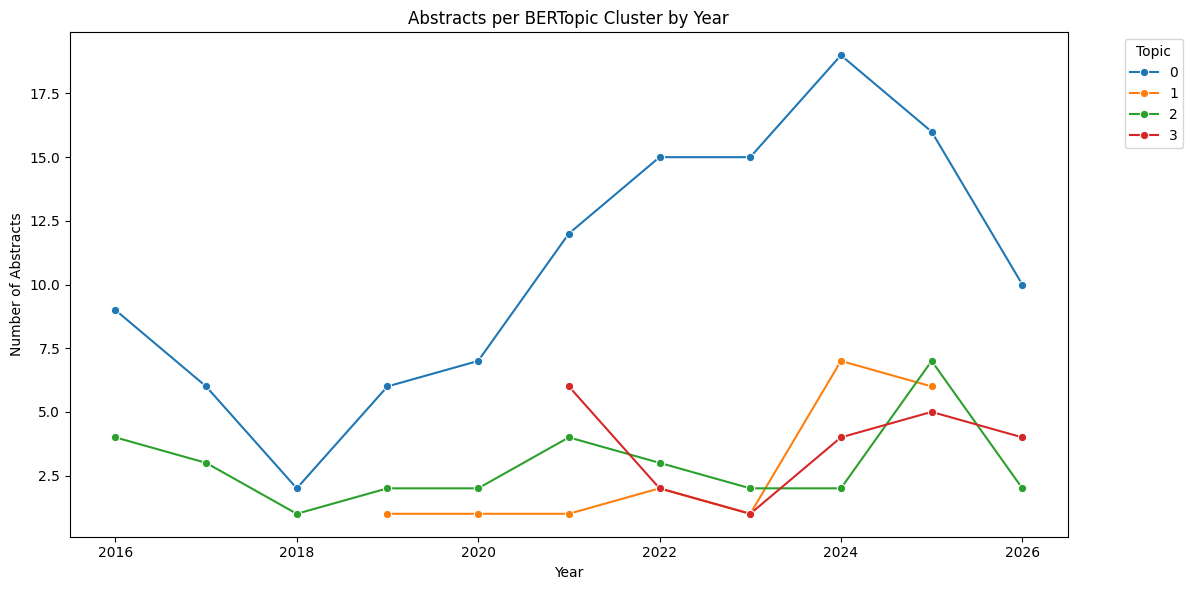

In [ ]:
abstracts_per_year = df.groupby("year").size().reset_index(name="count")

plt.figure(figsize=(10, 5))
sns.lineplot(data=abstracts_per_year, x="year", y="count", marker="o")
plt.title("Number of Included PubMed Abstracts by Year (2016–2026)")
plt.xlabel("Year")
plt.ylabel("Number of Abstracts")
plt.xticks(range(2016, 2027))
plt.tight_layout()
plt.show()

# Optional: abstracts per topic per year
topic_year = df[df["bertopic_topic"] != -1].groupby(
    ["year", "bertopic_topic"]
).size().reset_index(name="count")

plt.figure(figsize=(12, 6))
sns.lineplot(data=topic_year, x="year", y="count",
             hue="bertopic_topic", marker="o", palette="tab10")
plt.title("Abstracts per BERTopic Cluster by Year")
plt.xlabel("Year")
plt.ylabel("Number of Abstracts")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Quality Audit**

In [ ]:
# Build audit sample: 5–10 abstracts per top topic
top_topics = topic_ids[:10]   # top 10 non-outlier topics
audit_records = []

for topic_id in top_topics:
    topic_docs = topic_model.get_representative_docs(topic_id)
    sample = topic_docs[:10]  # up to 10 representative docs per topic
    matched = df[df["clean_abstract"].isin(sample)][
        ["pmid", "title", "abstract", "bertopic_topic"]
    ].copy()
    matched["topic"] = topic_id
    matched["llm_label"] = topic_info_llm[
        topic_info_llm["Topic"] == topic_id
    ]["Name"].values[0] if not topic_info_llm[
        topic_info_llm["Topic"] == topic_id
    ].empty else "Unknown"
    matched["llm_summary"] = summaries.get(topic_id, "")
    # Auditor fills in one of: accurate / partially accurate / hallucinated
    matched["summary_accuracy"] = ""
    matched["auditor_notes"] = ""
    audit_records.append(matched)

audit_df = pd.concat(audit_records, ignore_index=True)

print(f"Audit sample size: {len(audit_df)} abstracts across {len(top_topics)} topics")
print(audit_df[["pmid", "topic", "llm_label", "summary_accuracy"]].head(20))

# Export audit sheet for manual review
audit_df.to_csv("audit_sheet.csv", index=False)
print("Audit sheet saved to audit_sheet.csv")

Audit sample size: 12 abstracts across 4 topics
                                                 pmid  topic  \
0                                            38159755      0   
1                                            26828171      0   
2                                            26828167      0   
3                                            40701382      1   
4   40197324\n34843761\n34110593\n16935684\n964374...      1   
5                                            32961469      1   
6   31856877\n26960529\n31613318\n10698728\n226519...      2   
7                                            28778040      2   
8   27346385\n25935610\n22568888\n24887163\n269498...      2   
9                                            40952494      3   
10  40332678\n37050950\n17868821\n25468156\n209598...      3   
11  34444169\n34360159\n32191675\n27732126\n155794...      3   

                                  llm_label summary_accuracy  
0            0_Urban Heat Island Mitigation             

**AI- USE Disclosure:**

The initial code in Collab was inspired by Lab 6, and was edited and adjusted by myself without any AI. When encountering errors, I utilized ChatGPT and Google Gemini to debug, or explain errors pertaining to my code. Finally, for further organization and cleanup of the code I utilized Claude.